In [18]:
from preprocessing_class import Preprocessing, load_movies, load_pres
from sklearn.feature_extraction.text import CountVectorizer,TfidfVectorizer
from sklearn.model_selection import StratifiedShuffleSplit, train_test_split
from sklearn.cluster import KMeans
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC,SVC
from nltk.corpus import stopwords
from sklearn.preprocessing import StandardScaler
import numpy as np
import string
import matplotlib.pyplot as plt
import json
import pandas as pd
import seaborn as sns
from pathlib import Path

sns.set_style("darkgrid")


# config
DATASET = "movies"
RANDOM_STATE = 42
TEST_SIZE = 0.20
MAX_FEATURE = 5000
SAVING_FILE_NAME =  DATASET + "_ldalsa_"

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
def load_data(data_path, test_size=TEST_SIZE):
    print(data_path)
    print("DATASET ", DATASET)

    if DATASET == "pres":
        # Load and convert labels
        alltxt, alllabs = load_pres(data_path)
        alltxt = np.array(alltxt)
        # Convert labels: 1 -> 0, -1 -> 1
        alllabs = np.where(np.array(alllabs) == 1, 0, 1)
        
        print(f"Size train: {len(alltxt)}")
    else:
        alltxt,alllabs = load_movies(data_path)
        alltxt, alllabs = np.array(alltxt), np.array(alllabs)
        print(f"Size train: {len(alltxt)}")
    print(f"len: {len(alltxt)}, unique labels: {np.unique(alllabs)}")
    return alltxt, alllabs

In [10]:
path =  "Dataset/corpus.tache1.learn.utf8" if DATASET == "pres" else "./Dataset/movies1000/"
alltxt,alllabs = load_data(path)

./Dataset/movies1000/
DATASET  movies
Size train: 2000
len: 2000, unique labels: [0 1]


# 2) Latent Semantic Analysis (LSA <=> SVD)


**Remember the LSA factorziation**:
$$
\begin{matrix}
 & X  &\!\!\!\!\!=\!\!\!\!\!& U  & \Sigma & V^T \\
  & \textbf{t}_j   &  & \hat{ \textbf{d}_i} & &  \\
 & \downarrow  &  &\downarrow  & & \\
\textbf{d}_i \rightarrow
&
\begin{pmatrix}
x_{1,1} & \dots & x_{1,d} \\
\\
\vdots & \ddots & \vdots \\
\\
x_{N,1} & \dots & x_{N,d} \\
\end{pmatrix}
&
\!\!\!\!\!=\!\!\!\!\!
%&
%(\hat{ \textbf{t}_j}) \rightarrow
&
\begin{pmatrix}
\begin{pmatrix} &  \textbf{u}_1 &  \end{pmatrix} \\
\vdots \\
\begin{pmatrix}  & \textbf{u}_k &  \end{pmatrix}
\end{pmatrix}
%&
%\!\!\!\!\!\cdot\!\!\!\!\!
&
\begin{pmatrix}
\sigma_1 & \dots & 0 \\
\vdots & \ddots & \vdots \\
0 & \dots & \sigma_k \\
\end{pmatrix}
%&
%\!\!\!\!\!\cdot\!\!\!\!\!
&
\begin{pmatrix}
\begin{pmatrix} \, \\ \, \\ \textbf{v}_1 \\ \, \\ \,\end{pmatrix}
\dots
\begin{pmatrix} \, \\ \, \\ \textbf{v}_k \\ \, \\ \, \end{pmatrix}
\end{pmatrix}
\end{matrix}
$$

- Look at [SVD doc in skelarn](https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.TruncatedSVD.html#sklearn.decomposition.TruncatedSVD)
- Do the same qualitative/quantitative evaluation than with K-Means
- You can also use LSA as a pre-processing step for K-Means, *i.e.* running K-Means on $\boldsymbol{U}$ matrix above
    - N.B. : try without/with $\ell_2$ normalization of $\boldsymbol{U}$'s rows before running  K-Means
    - You can also benefit from LSA pre-processing for using [t-SNE visualization](https://scikit-learn.org/stable/modules/generated/sklearn.manifold.TSNE.html) (see code below)


#### U * sigma pour kmeans après

In [4]:
from sklearn.decomposition import TruncatedSVD 

vectorizer = CountVectorizer(stop_words="english")
vectorizer.fit(alltxt)
vectors = vectorizer.transform(alltxt)

svd = TruncatedSVD(n_components=10, n_iter=7, random_state=42) # choice of nb components
U = svd.fit_transform(vectors) # already U * S
kmeans = KMeans(n_clusters=10)
kmeans.fit(U)

,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",10
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",'auto'
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",300
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary `.",None
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'


In [5]:
clust_V = kmeans.cluster_centers_ @ svd.components_ # centre * V -> trouver mots dans clusters
clust_V.shape # 20 clusters

(10, 39354)

In [6]:
# 10 latent space and 20 clusters
feat_names = vectorizer.get_feature_names_out()
clust_V = svd.inverse_transform(kmeans.cluster_centers_) 
for i in range(kmeans.cluster_centers_.shape[0]):
    top_words = feat_names[np.argsort(np.abs(clust_V[i]))[::-1][:10]]
    print(f"Cluster {i}:", top_words)

Cluster 0: ['movie' 'film' 'like' 'just' 'time' 'story' 'good' 'life' 'way'
 'character']
Cluster 1: ['film' 'like' 'just' 'good' 'time' 'character' 'films' 'characters'
 'story' 'movie']
Cluster 2: ['film' 'like' 'just' 'movie' 'good' 'time' 'character' 'story'
 'characters' 'films']
Cluster 3: ['film' 'like' 'movie' 'just' 'good' 'time' 'character' 'story'
 'characters' 'films']
Cluster 4: ['film' 'star' 'wars' 'characters' 'movie' 'trek' 'effects' 'story'
 'special' 'new']
Cluster 5: ['film' 'black' 'cauldron' 'disney' 'taran' 'king' 'like' 'time' 'wen'
 'hen']
Cluster 6: ['movie' 'just' 'like' 'film' 'good' 'movies' 'time' 'bad' 'know' 'story']
Cluster 7: ['movie' 'film' 'like' 'just' 'good' 'time' 'bad' 'movies' 'character'
 'really']
Cluster 8: ['nbsp' 'series' 'movie' 'television' 'files' 'carter' 'characters'
 'alien' 'fans' 'like']
Cluster 9: ['film' 'movie' 'like' 'good' 'time' 'just' 'story' 'character' 'life'
 'way']


In [7]:
# t-SNE from the U matrix computed by LSA
from sklearn.manifold import TSNE
tsne = TSNE(n_components=2, init='pca',max_iter=5000, verbose=2)
tsne_mat = tsne.fit_transform(U)

[t-SNE] Computing 91 nearest neighbors...
[t-SNE] Indexed 2000 samples in 0.009s...
[t-SNE] Computed neighbors for 2000 samples in 0.136s...
[t-SNE] Computed conditional probabilities for sample 1000 / 2000
[t-SNE] Computed conditional probabilities for sample 2000 / 2000
[t-SNE] Mean sigma: 1.399732
[t-SNE] Computed conditional probabilities in 0.048s
[t-SNE] Iteration 50: error = 75.5019684, gradient norm = 0.0168366 (50 iterations in 0.936s)
[t-SNE] Iteration 100: error = 74.0634918, gradient norm = 0.0000575 (50 iterations in 0.663s)
[t-SNE] Iteration 150: error = 74.0625763, gradient norm = 0.0000312 (50 iterations in 0.563s)
[t-SNE] Iteration 200: error = 74.0626450, gradient norm = 0.0000301 (50 iterations in 0.564s)
[t-SNE] Iteration 250: error = 74.0627289, gradient norm = 0.0000323 (50 iterations in 0.569s)
[t-SNE] KL divergence after 250 iterations with early exaggeration: 74.062729
[t-SNE] Iteration 300: error = 1.9924904, gradient norm = 0.0184310 (50 iterations in 0.505s)

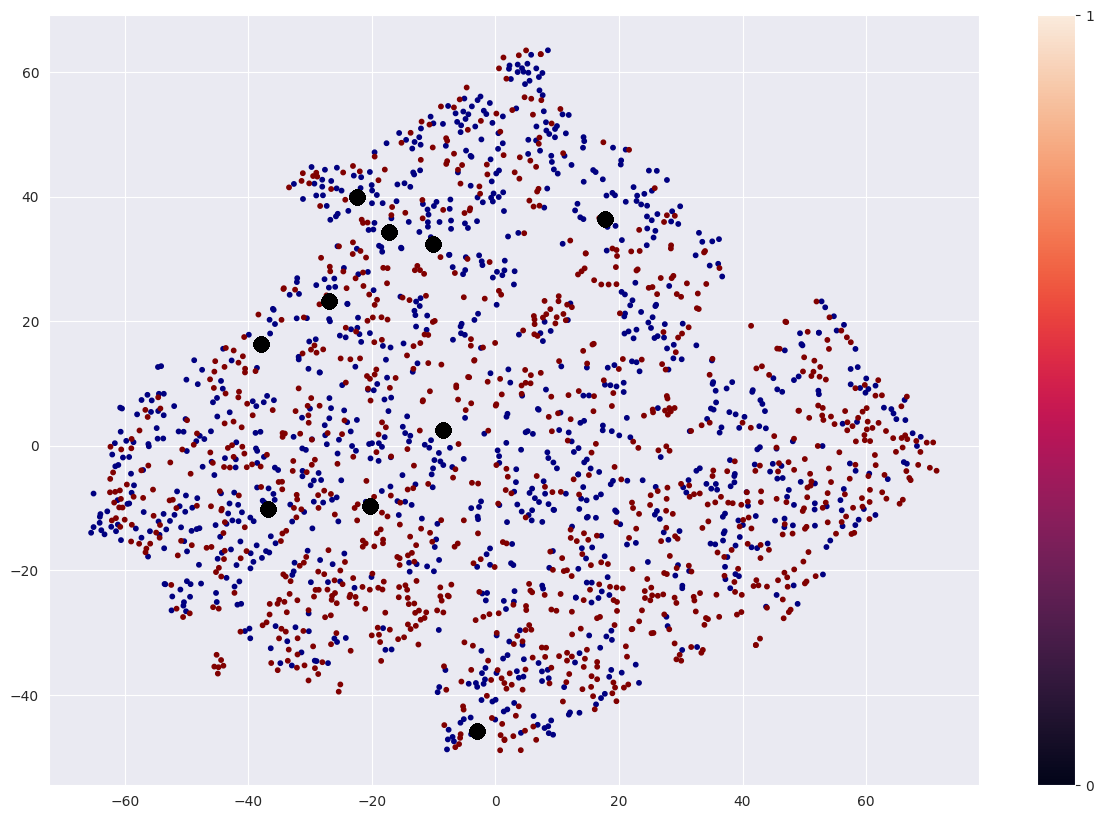

In [11]:
vectors_SVDn = svd.components_ # V matrix
NN2cluster = np.argmax(np.abs(vectors_SVDn), axis=0)
#import seaborn as sns
import matplotlib.cm as cm
from matplotlib.pyplot import get_cmap
cmap = cm.tab20
cmap = get_cmap('hsv', 20)
cmap = get_cmap('jet', 20)
#cmap = cm.tab20

plt.figure(figsize=(15,10))
plt.scatter(tsne_mat[:,0],tsne_mat[:,1], c=alllabs, cmap=cmap, s=10)
plt.scatter(tsne_mat[NN2cluster[:],0],tsne_mat[NN2cluster[:],1], c='black', s=100)
#plt.scatter(tsne_mat[NN2cluster2[:],0],tsne_mat[NN2cluster2[:],1], c='red', s=100)
plt.colorbar(ticks=range(20))

In [ ]:
#sns.set_style("whitegrid")
plt.rcParams.update({'font.size': 12})

# --- Step 1: Better TF-IDF + LSA ---
vectorizer = TfidfVectorizer(
    max_features=5000,    # limit vocab size
    min_df=2,             # ignore rare words
    max_df=0.95,          # ignore super common words
    stop_words='english',
    ngram_range=(1,2)     # unigrams + bigrams
)
vectors = vectorizer.fit_transform(alltxt)

# LSA: 50 components (good default for topic modeling)
n_topics = 50
svd = TruncatedSVD(n_components=n_topics, n_iter=15, random_state=42)
U = svd.fit_transform(vectors)  # document-topic matrix
S = svd.singular_values_        # singular values

print(f"Explained variance ratio: {svd.explained_variance_ratio_.sum():.3f}")

# --- Step 2: Find top words per topic ---
feat_names = vectorizer.get_feature_names_out()
topic_term_matrix = svd.components_  # topic x terms

for i in range(min(10, n_topics)):  # top 10 topics
    top_indices = np.argsort(np.abs(topic_term_matrix[i]))[::-1][:10]
    top_words = [feat_names[idx] for idx in top_indices]
    print(f"Topic {i}: {', '.join(top_words)}")

# --- Step 3: KMeans clustering on topic space ---
kmeans = KMeans(n_clusters=10, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(U)
cluster_centers = kmeans.cluster_centers_

# --- Step 4: Prettier t-SNE visualization ---
scaler = StandardScaler()
U_scaled = scaler.fit_transform(U)

tsne = TSNE(
    n_components=2,
    perplexity=5,        # good for your dataset size
    learning_rate=200,
    max_iter=2000,
    init='pca',
    random_state=42,
    method='exact'        # better quality
)
tsne_mat = tsne.fit_transform(U_scaled)


Explained variance ratio: 0.138
Topic 0: film, movie, like, just, good, time, story, characters, character, really
Topic 1: movie, alien, effects, special effects, life, aliens, action, special, bad, film
Topic 2: movie, film, alien, 10, wars, star wars, effects, funny, bad, aliens
Topic 3: jackie, scream, chan, horror, action, jackie chan, hong, damme, van damme, killer
Topic 4: film, jackie, scream, movie, chan, horror, disney, killer, tarzan, star wars
Topic 5: scream, jackie, star wars, wars, alien, chan, truman, phantom, phantom menace, lucas
Topic 6: disney, mulan, tarzan, film, truman, 10, scream, animated, animation, star wars
Topic 7: truman, 10, film, movie, carrey, scream, disney, tarzan, alien, life
Topic 8: truman, carrey, disney, film, movie, batman, tarzan, jim carrey, mulan, jim
Topic 9: alien, batman, jackie, aliens, film, ripley, vampire, comedy, chan, ship


ValueError: perplexity (30) must be less than n_samples (10)

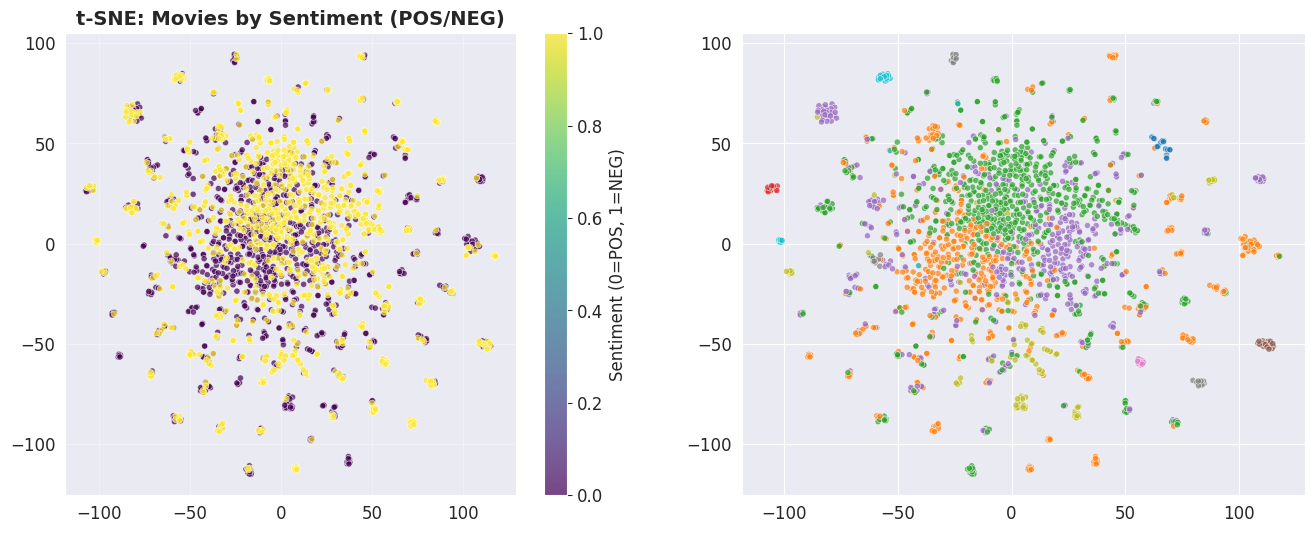

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: t-SNE colored by sentiment (your labels)
scatter1 = ax1.scatter(
    tsne_mat[:, 0], tsne_mat[:, 1],
    c=alllabs, cmap='viridis', s=20, alpha=0.7,
    linewidth=0.5
)
ax1.set_title('t-SNE: Movies by Sentiment (POS/NEG)', fontsize=14, fontweight='bold')
ax1.grid(True, alpha=0.3)
plt.colorbar(scatter1, ax=ax1, label='Sentiment (0=POS, 1=NEG)')

# Plot 2: t-SNE colored by clusters
scatter2 = ax2.scatter(
    tsne_mat[:, 0], tsne_mat[:, 1],
    c=cluster_labels, cmap='tab10', s=20, alpha=0.7,
    edgecolors='white', linewidth=0.5
)
# Highlight cluster centers
centers_tsne = tsne.fit_transform(scaler.transform(cluster_centers))
ax2.scatter(centers_tsne[:, 0], centers_tsne[:, 1],
            c='black', s=150, marker='X', linewidth=3, zorder=5)

ax2.set_title('t-SNE: LSA Topics + KMeans Clusters', fontsize=14, fontweight='bold')
ax2.grid(True, alpha=0.3)
plt.colorbar(scatter2, ax=ax2, label='Cluster ID')

plt.tight_layout()
plt.savefig('lsa_movies_tsne.pdf', dpi=300, bbox_inches='tight')
plt.show()

# --- Bonus: Scree plot for topic selection ---
plt.figure(figsize=(8, 5))
plt.plot(range(1, n_topics+1), S[:n_topics], 'o-', linewidth=2)
plt.xlabel('Topic Number')
plt.ylabel('Singular Value')
plt.title('LSA: Singular Values (Scree Plot)')
plt.grid(True, alpha=0.3)
plt.savefig('lsa_scree.pdf', dpi=300, bbox_inches='tight')
plt.show()

# 3) Latent Dirichlet Allocation (LDA)

Perform the same experiments with LDA:
- LDA
https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.LatentDirichletAllocation.html


**Start with a CountVectorizer**

In [ ]:
from nltk.tokenize import RegexpTokenizer
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

# Initialize regex tokenizer
tokenizer = RegexpTokenizer(r'\w+')

# Vectorize document using TF-IDF
vectorizer = CountVectorizer(lowercase=True,
                        stop_words='english',
                        ngram_range = (1,1),
                        tokenizer = tokenizer.tokenize, max_df=0.95, min_df=2, max_features=1000)

vectors = vectorizer.fit_transform(newsgroups_train.data)
print(vectors.shape)
print(vectors.nnz / float(vectors.shape[0]))

/home/franciline/anaconda3/lib/python3.12/site-packages/sklearn/feature_extraction/text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


(11314, 1000)
48.02527841612162


In [ ]:
from sklearn.decomposition import LatentDirichletAllocation

lda = LatentDirichletAllocation(n_components=15) # for the 15 topics
M = lda.fit_transform(vectors)

In [ ]:
M.shape # mots vs topics

(11314, 15)

In [ ]:
topics = np.argmax(M, axis=1) # taking the max is a clutering way 
# can apply kmeans after lda, as we have a new representation dimension

In [ ]:
kmeans = KMeans(n_clusters=10, random_state=42)
kmeans.fit(M)
labels = kmeans.labels_

In [ ]:
# top words per topic
feat_names = vectorizer.get_feature_names_out()

for topic_idx, topic in enumerate(lda.components_):
    top_words = feat_names[np.argsort(topic)[::-1][:10]]
    print(f"Topic {topic_idx}:", top_words)

Topic 0: ['edu' 's' 't' 'ca' 'game' 'team' 'year' 'games' 'play' 'university']
Topic 1: ['drive' 'scsi' 'disk' 'hard' 's' 'drives' 'controller' '2' 'ide' 'bus']
Topic 2: ['0' '1' 'm' '2' 'w' '3' '4' 'r' '5' '6']
Topic 3: ['edu' 'mail' 'uk' 'university' 'ac' 'cs' 'information' 'e' 'available'
 'computer']
Topic 4: ['t' 's' 'like' 'just' 'don' 'time' 'car' 'nasa' 'm' 'good']
Topic 5: ['s' 'q' 'mr' 'president' 'clinton' 't' 'going' 'stephanopoulos' 'tax'
 'think']
Topic 6: ['com' 't' 'writes' 'article' 'edu' 's' 'posting' 'don' 'nntp' 'host']
Topic 7: ['x' 'file' 'window' 'windows' '1' 'program' 's' '0' 'c' 'use']
Topic 8: ['1' 'com' 'edu' '2' 'card' 'ibm' 'windows' 'hp' '3' 'posting']
Topic 9: ['key' 'government' 'edu' 'state' 'encryption' 'chip' 'clipper' 's'
 'access' 'law']
Topic 10: ['ax' 'max' 'q' '3' 'p' 'm' '7' 'r' 'g9v' 'g']
Topic 11: ['t' 's' 'people' 'god' 'edu' 'think' 'don' 'say' 'just' 'know']
Topic 12: ['edu' '_' 'university' 'article' 'writes' 'posting' 'host' 'nntp' 'cc'


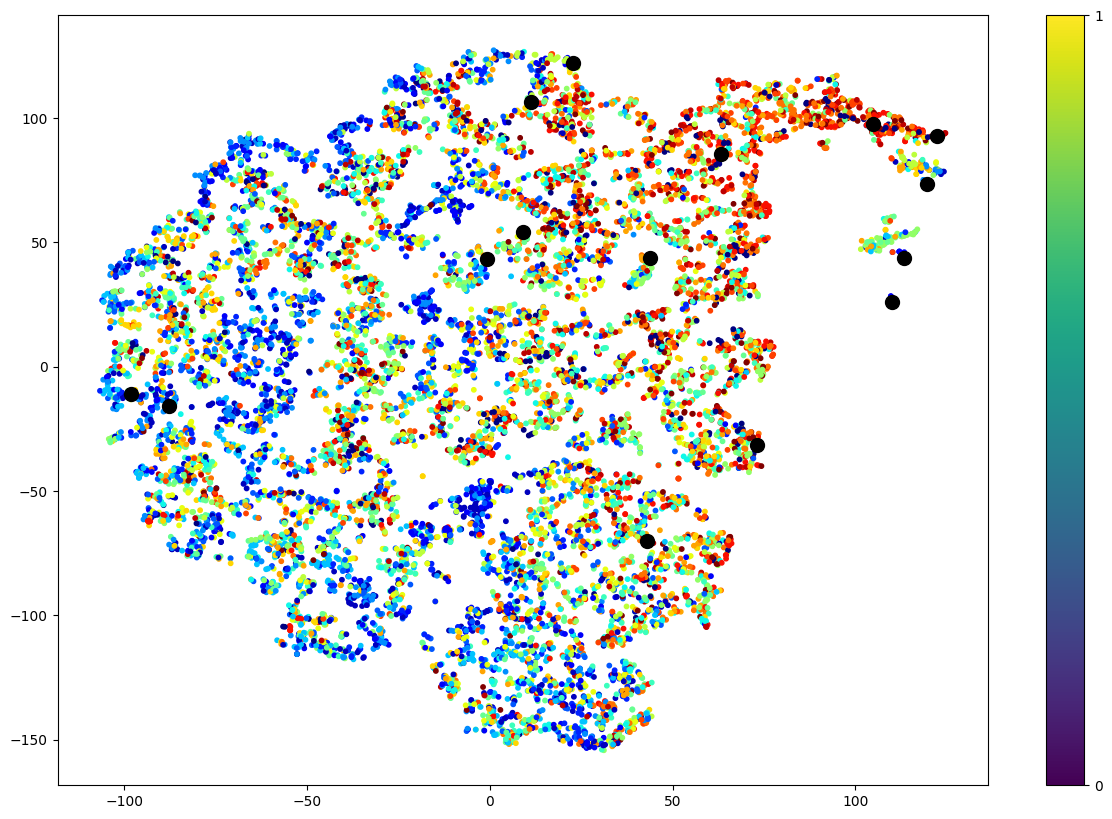

In [ ]:
NN2cluster = np.argmax(np.abs(M), axis=0) 
#import seaborn as sns
import matplotlib.cm as cm
from matplotlib.pyplot import get_cmap
cmap = cm.tab20
cmap = get_cmap('hsv', 20)
cmap = get_cmap('jet', 20)
#cmap = cm.tab20

plt.figure(figsize=(15,10))
plt.scatter(tsne_mat[:,0],tsne_mat[:,1], c=Y, cmap=cmap, s=10,)
plt.scatter(tsne_mat[NN2cluster[:],0],tsne_mat[NN2cluster[:],1], c='black', s=100)
plt.colorbar(ticks=range(20))
# plt.legend()
#plt.scatter(tsne_mat[NN2cluster2[:],0],tsne_mat[NN2cluster2[:],1], c='red', s=100)